## 11장 신경망 모델 훈련

### 1. 손실 곡선

1.1 패션 MNIST 데이터셋을 적재하고 훈련세트와 검증세트를 분리.

In [30]:
# 필요한 라이브러리를 임포트한다.
from tensorflow import keras
from sklearn.model_selection import train_test_split

# 패션 MNIST 데이터셋을 로드한다.
(train_input, train_target), (test_input, test_target) = \
  keras.datasets.fashion_mnist.load_data()

# 훈련데이터를 0~1 사이의 값으로 정규화한다.
train_scaled = train_input / 255.0

# 훈련세트와 검증세트를 분리한다.
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

1.2 신경망 모델을 만드는 함수 만들기

In [31]:
def model_fn(a_layer=None):
  # 신경망 모델을 생성한다.
  model = keras.Sequential()

  # Flatten 층을 추가한다.
  model.add(keras.layers.Flatten(input_shape=(28, 28)))

  # 뉴런이 100개인 Dense 층을 추가한다.
  model.add(keras.layers.Dense(100, activation='relu'))

  # 매개변수 a_layer가 값이 있으면 Dense 층을 추가한다.
  if a_layer :
    model.add(a_layer)

  # 뉴런이 10개인 Dense층을 추가한다.
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model

In [32]:
# a_layer 매개변수로 층을 추가하지 않고 함수를 호출한다.
model = model_fn()

# 모델의 요약정보를 확인한다.
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_8 (Dense)             (None, 100)               78500     
                                                                 
 dense_9 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


1.3 훈련결과를 저장하고 확인하기

In [33]:
# 모델을 훈련시키기 전에 설정을 지정한다.
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')

# 훈련 결과를 history에 저장한다.
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)

In [34]:
# history 객체에는 훈련 측정값이 담겨 잇는 history 딕셔너리가 들어있다.
# history 딕셔너리에는 어떤 값들이 들어있는지 확인한다.
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


In [35]:
# 모델을 훈련시키기 전에 설정을 지정한다.
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')

# 훈련 결과를 history에 지정한다.
# verbose=1 은 훈련과정을 나타낸다.
history = model.fit(train_scaled, train_target, epochs=5, verbose=1)

Epoch 1/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3087 - accuracy: 0.8898
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3003 - accuracy: 0.8945
Epoch 3/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2897 - accuracy: 0.8972
Epoch 4/5
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2827 - accuracy: 0.9004
Epoch 5/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2771 - accuracy: 0.9031


1.4 훈련결과로 그래프 그리기

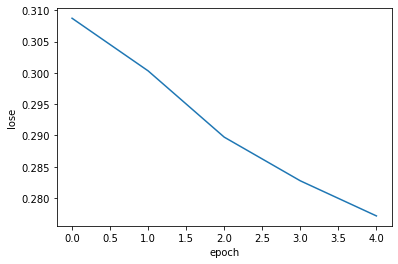

In [36]:
import matplotlib.pyplot as plt

# 손실값을 그래프로 그린다.
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('lose')

# savefig()으로 그래프를 이미지로 저장한다.
# dpi(Dots per Inch)는 이미지의 해상도를 설정한다. 기본값은 dpi=100
plt.savefig('loss_epo5', dpi=300)
plt.show()

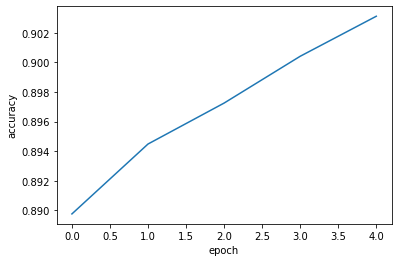

In [37]:
# 정확도를 그래프로 그린다.
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.savefig('accc_epo5', dpi=300)
plt.show()

1.5 에포크를 20으로 지정하고 훈련시키기

In [38]:
# 함수를 호출하여 신경망 모델을 다시 생성한다.
model = model_fn()

# 에포크를 20으로 지정하고 훈련시킨다.
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

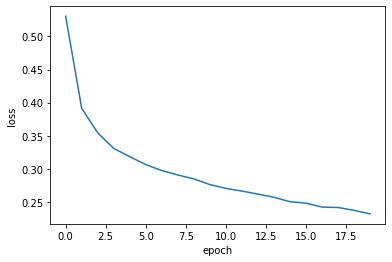

In [39]:
# 손실값을 그래프로 그린다.
# 에포크가 클수록 손실값이 감소하는 것을 확인할 수 있다.
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig('loss_epo20', dpi=300)
plt.show()

### 2. 검증 손실

2.1 에포크마다 검증 손실을 계산하기

In [40]:
model= model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')

# fit()의 validate_data 매개변수에 검증에 사용할 입력과 타깃값을 전달한다.
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

In [41]:
# 반환된 history객체의 history 딕셔너리에 어떤값이 들어있는지 확인한다.
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


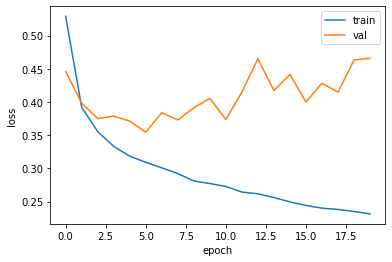

In [42]:
# 훈련 손실을 그래프로 그린다.
plt.plot(history.history['loss'])

# 검증 손실을 그래프로 그린다.
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.savefig('val_loss_epo5', dpi=300)
plt.show()

### 3. 드롭아웃

3.1 드롭아웃층 추가하기

In [43]:
# 위에서 만든 model_fn()을 이용하여 30% 정도를 드롭아웃층을 추가한다.
model = model_fn(keras.layers.Dropout(0.3))

model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_7 (Flatten)         (None, 784)               0         
                                                                 
 dense_14 (Dense)            (None, 100)               78500     
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense_15 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [45]:
# 드롭아웃 층을 추가하고 다시 신경망 모델을 훈련시킨다.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

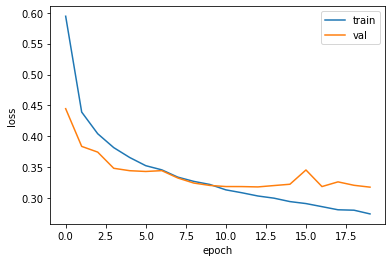

In [46]:
# 훈련 손실을 그래프로 그린다.
plt.plot(history.history['loss'])

# 검증 손실을 그래프로 그린다.
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.savefig('dropout', dpi=300)
plt.show()